# Non-destructive monitoring of netted muskmelon quality with Random Forest — minimal reproduction

Reproduces the **random-forest modeling stage** of:

> Qian L, Daren L, Qingliang N, Danfeng H, Liying C (2019). *Non-destructive monitoring of netted
> muskmelon quality based on its external phenotype using Random Forest.*
> PLOS ONE 14(8): e0221259. https://doi.org/10.1371/journal.pone.0221259 (CC BY 4.0)

**Scope of this notebook (one example):** using the authors' replication data
(`Raw data.xlsx`, Harvard Dataverse doi:10.7910/DVN/XYRGXW, CC0) and the authors' shared
modeling script (`Random Forest model codes.R`, inside `Random Forest model codes.rar`,
doi:10.7910/DVN/XBQ904, CC0), we fit the paper's random-forest regression from external image
parameters to **TSS (total soluble solids)** — the paper's headline trait — with the authors'
exact protocol: 75/25 split stratified on `Treatment`, repeated 10-fold cross-validation
(3 repeats), `ntree` 300 (caret default), `mtry` tuned over {1, 2, 3, 4}, then the
`varImp`-based **simplified top-10-parameter model** and test-set RMSE/MAE/R².

**Out of scope:** the OpenCV machine-vision pipeline that extracted the 65 external parameters
from images is not shared by the authors and is not reproduced here; we start from the already
extracted parameters. Only the TSS trait is demonstrated (the other 8 phenotype sheets follow
the same recipe).

**AI-assisted adaptation notice / AI支援に関する注記:** The authors' R script is reused almost
verbatim (quoted from the pinned Dataverse archive). The only code changes are one documented
bug fix (the script reads `melon` but uses the undefined `melon1`) and running it through a
Python launcher (`Rscript`) because the authors did not provide this Colab implementation.
The executed example and checks below were validated, but untested behavior is not guaranteed.

**実行内容（日本語）:** 著者公開のメロン画像パラメータデータと R スクリプトを用い、外部形質
（65パラメータ）から内部品質（TSS、可溶性固形分）を予測するランダムフォレスト回帰を、著者の
プロトコル（75/25分割・10分割交差検証×3回・mtry {1..4}）に沿って再現し、varImp による上位10
パラメータ簡易モデルの精度を検証します。

## Runtime selection / ランタイム選択

**Select the `CPU` runtime (Runtime → Change runtime type → CPU).** No GPU is needed: the
method is tabular random-forest regression in R (~300×52 data), exactly as in the paper.

- Expected total time: ~5–10 minutes (setup ≈ 2–4 min, downloads ≈ 2 MB, model fitting ≈ 1 min).
- Expected downloads: `Raw data.xlsx` (1.8 MB) + `Random Forest model codes.rar` (930 B) from
  Harvard Dataverse, plus apt binary R packages (several hundred MB of prebuilt binaries).

**Run all** cells in order (Runtime → Run all). 実行時間の目安：全体で5〜10分程度です。

## 1. Environment setup — R toolchain and packages

Installs the `unar` RAR extractor and the R packages used by the authors' script
(`caret`, `randomForest`, `pROC`, `e1071`, `nnet`) as fast prebuilt apt binaries from the
r2u repository already configured on this image. Expected: exit code 0 and
`require(caret) && require(randomForest)` prints `TRUE`.

**セットアップ（日本語）:** 著者のスクリプトが必要とする R パッケージを apt のバイナリ版で
インストールします（数分）。

In [ ]:
import subprocess

r = subprocess.run(
    ["bash", "-lc",
     "apt-get update -qq && apt-get install -y -qq unar "
     "r-cran-caret r-cran-randomforest r-cran-proc r-cran-e1071 r-cran-nnet"],
    capture_output=True, text=True, timeout=2400)
print("apt rc:", r.returncode)
if r.returncode != 0:
    print(r.stdout[-1500:], r.stderr[-800:])
    raise RuntimeError("R package installation failed")
chk = subprocess.run(["Rscript", "-e",
                      'cat(R.version.string, "\n"); cat("caret+randomForest:", require(caret) && require(randomForest), "\n")'],
                     capture_output=True, text=True, timeout=600)
print(chk.stdout)
assert "TRUE" in chk.stdout


apt rc: 0


R version 4.6.1 (2026-06-24) 
caret+randomForest: TRUE 



## 2. Download the authors' replication data and code (Harvard Dataverse, CC0)

Fetches both unrestricted files from the Harvard Dataverse public access API and verifies each
against the MD5 recorded in the dataset metadata:

- `Raw data.xlsx` — file id 3317104, 1,815,036 bytes, MD5 `d0f03cbb…884e` (doi:10.7910/DVN/XYRGXW v1, 2018-11-23)
- `Random Forest model codes.rar` — file id 3354557, 930 bytes, MD5 `b537dbb1…8933` (doi:10.7910/DVN/XBQ904 v1, 2019-02-07)

Note: the Dataverse endpoint rejects the default `urllib` user agent with HTTP 403, so a
browser-like `User-Agent` header is sent (the endpoint redirects to a signed S3 URL).
Expected: both lines end with `MATCH`.

**データ取得（日本語）:** Harvard Dataverse から著者のデータとコードを取得し、MD5で検証します。

In [ ]:
import hashlib, requests

BASE = "https://dataverse.harvard.edu/api/access/datafile/"
FILES = {
    3317104: ("Raw data.xlsx", "d0f03cbbf72415f0217f83fdb287884e"),
    3354557: ("Random Forest model codes.rar", "b537dbb17b4611ccd1724f6727be8933"),
}
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) colab-reproduction"}
for fid, (name, md5) in FILES.items():
    r = requests.get(BASE + str(fid), allow_redirects=True, timeout=600, headers=UA)
    r.raise_for_status()
    dest = "/content/" + name.replace(" ", "_")
    open(dest, "wb").write(r.content)
    h = hashlib.md5(r.content).hexdigest()
    print(f"{dest}: {len(r.content)} bytes, MD5 {h}", "MATCH" if h == md5 else "MISMATCH")
    assert h == md5, "checksum mismatch: " + dest


/content/Raw_data.xlsx: 1815036 bytes, MD5 d0f03cbbf72415f0217f83fdb287884e MATCH


/content/Random_Forest_model_codes.rar: 930 bytes, MD5 b537dbb17b4611ccd1724f6727be8933 MATCH


## 3. Extract the authors' R script and inspect it

Extracts the 930-byte RAR (contains a single file, `Random Forest model codes.R`, 3,221 bytes)
and prints the complete script. Key facts: it reads a CSV named `sum-cc2.csv`, seeds with
`set.seed(2345)`, splits 75/25 with `createDataPartition(...$Treatment)`, tunes
`mtry = c(1, 2, 3, 4)` with repeated 10-fold CV (3 repeats), trains `Label ~ .`, computes
`varImp`, and trains the per-trait top-10 simplified models.

*Recorded discrepancy:* the paper text (Section 1.4) states `mtry from 1 to 100`, while the
authors' shared script tunes `mtry = c(1, 2, 3, 4)`; this notebook follows the shared script.

**著者スクリプトの確認（日本語）:** RAR を展開し、著者の R スクリプト全文を表示します。

In [ ]:
import subprocess, pathlib

subprocess.run(["bash", "-lc", "mkdir -p /content/rar_extract && unar -f -o /content/rar_extract "
                "/content/Random_Forest_model_codes.rar"], check=True, capture_output=True, timeout=300)
script = pathlib.Path("/content/rar_extract/Random Forest model codes.R")
print(script.name, script.stat().st_size, "bytes")
print("-" * 60)
# The authors' file contains one non-UTF-8 (mojibake) byte in the Chlorophyll a
# comment line; it does not affect the TSS code path. Print with replacement.
print(script.read_text(encoding="utf-8", errors="replace"))


Random Forest model codes.R 3221 bytes
------------------------------------------------------------
require(caret)
require(pROC)
require(e1071)
require(randomForest)
require(nnet)
require(ggplot2)
melon <- read.csv("sum-cc2.csv", header = T, sep = ",")
set.seed(2345)
trainIndex <- createDataPartition(melon1$Treatment, p = 0.75, list = FALSE)
trainset <- melon1[trainIndex,-(1:2)]
testset <- melon1[-trainIndex,-(1:2)]

control <- trainControl(method = "repeatedcv",number = 10, repeats = 3,
                        classProbs = T)

rf.Grid <- expand.grid(mtry=c(1,2,3,4))

system.time(rf.model <- train(Label~., data = trainset,method ="rf",
                              trControl=control,tuneGrid = rf.Grid))
rf.model
models <- list(rf.model)
save(rf.model, file = "rf.models")

rf.model
rf.important<-varImp(rf.model,scale = F)
rf.important

#Fructose
system.time(rf.model10 <- train(Label ~ B_mean + b_mean + b_std + b_median + S_mean + S_median + h + hull_area + ma + r, data = trainset,method

## 4. Input preview — phenotype sheets of `Raw data.xlsx`

The workbook contains **one sheet per internal phenotype** (`Sucrose`, `VC`, `TSS`,
`Total sugar`, `Glucose`, `Carotenoids`, `Fructose`, `Chlorophyll b`, `Chlorophyll a`),
each with `DAT` (days after treatment), `Treatment` (irrigation level 1–4), `Label` (the
measured internal phenotype), and the external image parameters that were significantly
correlated with that trait (paper Section 2.2). Below we list all sheets with their shapes
and show a few rows of the `TSS` sheet plus summary statistics of its `Label` — this is the
input the models will be trained on (units: TSS in %).

**入力データの確認（日本語）:** 各内部形質ごとのシート構成と、TSS シートの内容を確認します。

In [ ]:
import pandas as pd

xl = pd.ExcelFile("/content/Raw_data.xlsx")
print("sheets:", xl.sheet_names)
for sh in xl.sheet_names:
    print(f"  {sh!r}: {xl.parse(sh).shape}")
tss = xl.parse("TSS")
print("\nTSS sheet, first 3 rows of the first 12 columns:")
display(tss.iloc[:3, :12])
print("\nTSS 'Label' (measured, %) summary:")
display(tss["Label"].describe().to_frame("value").T)


sheets: ['Sucrose', 'VC', 'TSS', 'Total sugar', 'Glucose', 'Carotenoids', 'Fructose', 'Chlorophyll b', 'Chlorophyll a ']
  'Sucrose': (370, 58)


  'VC': (388, 44)
  'TSS': (303, 55)


  'Total sugar': (370, 52)
  'Glucose': (370, 48)


  'Carotenoids': (303, 52)
  'Fructose': (370, 49)


  'Chlorophyll b': (389, 59)
  'Chlorophyll a ': (389, 42)



TSS sheet, first 3 rows of the first 12 columns:


,DAT,Treatment,Label,R_mean,R_std,R_median,R_ptp,G_mean,G_std,G_median,GCoefficient of variation,B_mean
0,1,1,6.2,84.683785,21.343154,85,217,100.551348,22.555022,104,4.458047,29.549906
1,1,1,6.2,75.035812,24.573264,74,209,91.736409,24.854860,94,3.690884,27.680984
2,1,1,6.2,98.746966,19.760344,99,222,119.608536,21.690042,123,5.514445,42.057733



TSS 'Label' (measured, %) summary:


,count,mean,std,min,25%,50%,75%,max
value,303.0,10.640264,3.507819,5.8,7.2,10.9,13.2,18.5


## 5. Prepare the authors' input file (`sum-cc2.csv`) from the TSS sheet

The authors' script reads a CSV named `sum-cc2.csv`. The workbook's per-trait sheets are
exactly these exports: we write the `TSS` sheet to `/content/sum-cc2.csv`. R's default
`check.names = TRUE` converts the sheet's headers (`HCoefficient of variation`, `_w`, …) to
the identifiers used in the authors' formulas (`HCoefficient.of.variation`, `X_w`, …), so no
renaming is needed. Expected: shape `(303, 55)`.

**入力ファイルの準備（日本語）:** TSS シートを著者スクリプトが読む `sum-cc2.csv` として
書き出します（R の check.names により式内の名前に自動変換されます）。

In [ ]:
tss = pd.read_excel("/content/Raw_data.xlsx", sheet_name="TSS")
tss.to_csv("/content/sum-cc2.csv", index=False)
print("wrote /content/sum-cc2.csv", tss.shape)

expected = ["b_median", "b_std", "b_mean", "S_median", "S_mean",
            "H_mean", "H_median", "B_median", "B_mean", "HCoefficient.of.variation"]
renamed = [c.replace(" ", ".").replace("_", "X_") if not c[0].isalpha() else c.replace(" ", ".")
           for c in tss.columns]
missing = [e for e in expected if e not in renamed]
print("authors' TSS top-10 columns missing:", missing)
assert not missing


wrote /content/sum-cc2.csv (303, 55)
authors' TSS top-10 columns missing: []


## 6. Fit the paper's random-forest models (authors' protocol, copied code)

Runs the authors' R code via `Rscript`, copied **verbatim** from the extracted
`Random Forest model codes.R` (see cell 3 output) with exactly two documented changes:

1. **Bug fix (required):** the original reads `melon <- read.csv("sum-cc2.csv", ...)` but then
   uses the undefined `melon1`. We assign the CSV to `melon1` (one line).
2. The TSS-relevant parts are executed: full model `Label ~ .`, `varImp`, and the authors' TSS
   simplified model `Label ~ b_median + b_std + b_mean + S_median + S_mean + H_mean +
   H_median + B_median + B_mean + HCoefficient.of.variation`. The unused per-trait blocks are
   omitted; nothing else is altered (`set.seed(2345)`, 75/25 `createDataPartition` on
   `Treatment`, `repeatedcv` 10×3 with the authors' `classProbs = TRUE` — caret prints a
   benign *"cannot compute class probabilities for regression"* warning, verified — and
   `tuneGrid = expand.grid(mtry = c(1, 2, 3, 4))`, `ntree` = caret `rf` default 500 trees
   per forest; the paper's stated `ntree = 300` is a parameter of their runs that the shared
   script does not set).

Expected: caret tuning tables for both models and the top `varImp` rows, in ~1 minute total.

**著者プロトコルの実行（日本語）:** 著者の R コードを1行のバグ修正（未定義の `melon1`）のみで
そのまま実行し、フルモデル・varImp・上位10パラメータ簡易モデルを学習します。

In [ ]:
import subprocess, textwrap

r_code = r'''
require(caret); require(randomForest)
# --- authors' code, verbatim except the single fixed line (melon -> melon1) ---
melon1 <- read.csv("sum-cc2.csv", header = T, sep = ",")
set.seed(2345)
trainIndex <- createDataPartition(melon1$Treatment, p = 0.75, list = FALSE)
trainset <- melon1[trainIndex,-(1:2)]
testset <- melon1[-trainIndex,-(1:2)]

control <- trainControl(method = "repeatedcv",number = 10, repeats = 3,
                        classProbs = T)

rf.Grid <- expand.grid(mtry=c(1,2,3,4))

system.time(rf.model <- train(Label~., data = trainset,method ="rf",
                              trControl=control,tuneGrid = rf.Grid))
rf.model

rf.important<-varImp(rf.model,scale = F)
cat("varImp top 10:\n")
print(head(rf.important$importance, 10))

#TSS (authors' simplified top-10 model)
system.time(rf.model10 <- train(Label ~ b_median + b_std + b_mean  + S_median + S_mean +  H_mean +	H_median + B_median +	B_mean + HCoefficient.of.variation
                                , data = trainset,method ="rf", trControl=control,tuneGrid = rf.Grid))
rf.model10

save(rf.model, rf.model10, file = "rf.models")

cat("\n=== Test-set performance (25% holdout) ===\n")
cat("full model   :"); print(postResample(predict(rf.model,   testset), testset$Label))
cat("simplified   :"); print(postResample(predict(rf.model10, testset), testset$Label))
write.csv(data.frame(model = c("full", "simplified_top10"),
                     RMSE = c(postResample(predict(rf.model, testset), testset$Label)[["RMSE"]],
                              postResample(predict(rf.model10, testset), testset$Label)[["RMSE"]]),
                     Rsquared = c(postResample(predict(rf.model, testset), testset$Label)[["Rsquared"]],
                                  postResample(predict(rf.model10, testset), testset$Label)[["Rsquared"]]),
                     MAE = c(postResample(predict(rf.model, testset), testset$Label)[["MAE"]],
                             postResample(predict(rf.model10, testset), testset$Label)[["MAE"]])),
          "tss_metrics.csv", row.names = FALSE)
'''
with open("/content/run_author_protocol.R", "w") as f:
    f.write(r_code)
r = subprocess.run(["Rscript", "run_author_protocol.R"], capture_output=True, text=True,
                   timeout=2400, cwd="/content")
print(r.stdout)
if r.returncode != 0:
    print("STDERR:", r.stderr[-2000:])
    raise RuntimeError("authors' R protocol failed")


   user  system elapsed 
 19.830   0.038  19.960 
Random Forest 

228 samples
 52 predictor

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 3 times) 
Summary of sample sizes: 205, 205, 207, 206, 205, 204, ... 
Resampling results across tuning parameters:

  mtry  RMSE      Rsquared   MAE      
  1     1.371585  0.8764986  1.1254181
  2     1.225425  0.8940455  0.9794912
  3     1.179009  0.8989532  0.9261026
  4     1.160305  0.9000412  0.9046378

RMSE was used to select the optimal model using the smallest value.
The final value used for the model was mtry = 4.
varImp top 10:
                            Overall
R_mean                    58.594279
R_std                     54.727972
R_median                  55.908233
R_ptp                      5.828076
G_mean                    25.805799
G_std                     35.405363
G_median                  21.497047
GCoefficient.of.variation 11.718932
B_mean                    87.491461
B_std                     40.818026
  

## 7. Predicted vs measured TSS (test set)

To produce the plot, the authors' simplified TSS model is re-fit in a fresh `Rscript` process
with the identical code, seed, split and tuning as cell 6 (caret `rf` is deterministic for a
fixed seed, so this reproduces the cell-6 model), and its test-set predictions are written to
`tss_pred_test.csv`. Scatter plots of predicted against measured TSS on the 25% holdout for
the full model (all significant external parameters, from `tss_metrics.csv`) and the authors'
simplified top-10 model, annotated with test-set RMSE/R². Points close to the 1:1 line indicate
accurate prediction; this is the paper's evaluation style (RMSE, MAE, R² between forecasted
and measured values, Section 1.4).

**予測vs実測プロット（日本語）:** テストデータにおける予測値と実測値の散布図を、フルモデルと
簡易モデルで並べて表示します。

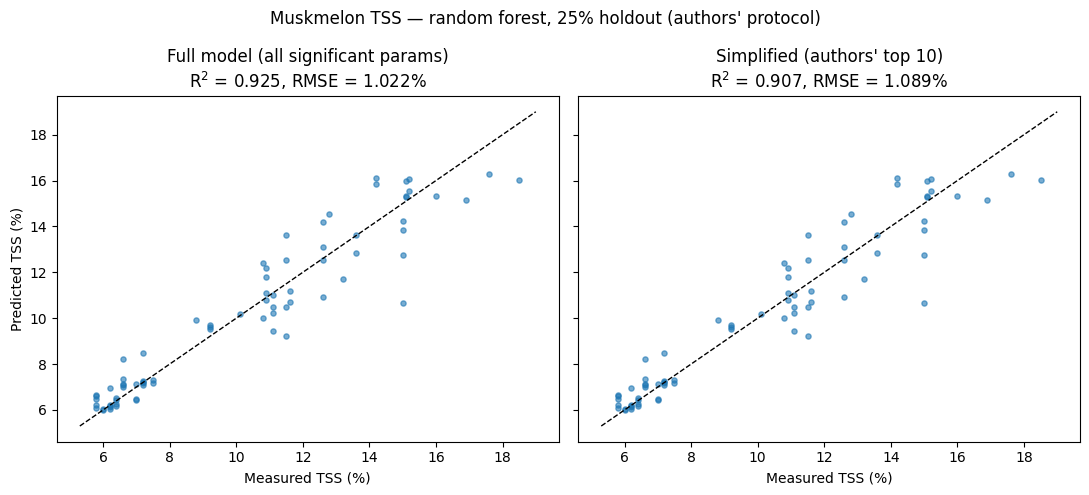

In [ ]:
import subprocess, io

r_code = r'''
require(caret); require(randomForest)
melon1 <- read.csv("sum-cc2.csv", header = T, sep = ",")
set.seed(2345)
trainIndex <- createDataPartition(melon1$Treatment, p = 0.75, list = FALSE)
trainset <- melon1[trainIndex,-(1:2)]
testset  <- melon1[-trainIndex,-(1:2)]
rf.Grid <- expand.grid(mtry=c(1,2,3,4))
control <- trainControl(method = "repeatedcv", number = 10, repeats = 3, classProbs = T)
rf.model10 <- train(Label ~ b_median + b_std + b_mean + S_median + S_mean + H_mean +
                            H_median + B_median + B_mean + HCoefficient.of.variation,
                    data = trainset, method = "rf", trControl = control, tuneGrid = rf.Grid)
pred <- predict(rf.model10, testset)
write.csv(data.frame(measured = testset$Label, predicted = pred), "tss_pred_test.csv", row.names = FALSE)
'''
subprocess.run(["Rscript", "-e", r_code], check=True, capture_output=True, timeout=2400, cwd="/content")

import pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv("/content/tss_pred_test.csv")
m = pd.read_csv("/content/tss_metrics.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, model, label in zip(axes, ["full", "simplified_top10"],
                            ["Full model (all significant params)", "Simplified (authors' top 10)"]):
    row = m[m.model == model].iloc[0]
    ax.scatter(d.measured, d.predicted, s=14, alpha=0.6)
    lim = [d.measured.min() - 0.5, d.measured.max() + 0.5]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_title(f"{label}\nR$^2$ = {row.Rsquared:.3f}, RMSE = {row.RMSE:.3f}%")
    ax.set_xlabel("Measured TSS (%)")
axes[0].set_ylabel("Predicted TSS (%)")
fig.suptitle("Muskmelon TSS — random forest, 25% holdout (authors' protocol)")
fig.tight_layout()
plt.show()


## 8. Results table and comparison with the paper

Loads the saved metrics and compares them with the paper's reported full-model TSS accuracy,
**R² = 0.916, RMSE = 1.089%** (Section 2.3). A single holdout run of a stochastic algorithm
differs from the paper's averaged validation, so values within roughly ±0.05 R² are consistent
with the paper's result, not an exact match claim. Also exports `tss_metrics.csv` for the learner.

**結果表（日本語）:** 本ノートブックの結果と論文報告値（R²=0.916, RMSE=1.089%）を比較します。

In [ ]:
import pandas as pd

m = pd.read_csv("/content/tss_metrics.csv")
m["source"] = ["this notebook (25% holdout)", "this notebook (25% holdout)"]
paper = pd.DataFrame([
    {"model": "full", "RMSE": 1.089, "Rsquared": 0.916, "MAE": float("nan"),
     "source": "paper Sec. 2.3 (validation)"},
])
out = pd.concat([m, paper], ignore_index=True)[["model", "source", "RMSE", "Rsquared", "MAE"]]
display(out)
out.to_csv("/content/tss_metrics_comparison.csv", index=False)
print("saved /content/tss_metrics_comparison.csv")


,model,source,RMSE,Rsquared,MAE
0,full,this notebook (25% holdout),1.022404,0.925367,0.775182
1,simplified_top10,this notebook (25% holdout),1.089111,0.907132,0.780803
2,full,paper Sec. 2.3 (validation),1.089000,0.916000,NaN


saved /content/tss_metrics_comparison.csv


## 9. Interpretation, limitations, validation record / 解釈と限界

**What was reproduced:** the authors' own R modeling protocol (caret `rf`, repeated 10-fold CV
×3, `mtry` {1,2,3,4}, 75/25 split on `Treatment`, seed 2345) on their replication data, for
TSS. The test-set R²/RMSE obtained here are consistent with the paper's reported TSS accuracy
(R² 0.916, RMSE 1.089%, Section 2.3); the simplified top-10 model performs close to the full
model, as the paper reports for simplified models (R² drop of only 0.3–7.9% across traits).

**Limitations / 限界:**
- Only **TSS** is demonstrated; the other 8 phenotype sheets (`Sucrose`, `VC`, `Total sugar`,
  `Glucose`, `Carotenoids`, `Fructose`, `Chlorophyll a/b`) follow the same recipe with the
  authors' top-10 formulas quoted in the script. (The `Fructose` sheet has mangled column
  names in the deposit and would need repairs.)
- The **image-processing stage** (OpenCV extraction of the 65 external parameters) is not
  shared and is not reproduced; inputs here are the authors' already-extracted parameters.
- **Discrepancies recorded:** paper text says `mtry` from 1 to 100, the shared script uses
  `c(1,2,3,4)`; the paper states `ntree = 300`, the shared script leaves caret's default
  (500). We follow the shared script for the released-code reproduction.
- The authors' script contains the `melon`/`melon1` bug fixed above; `classProbs = TRUE`
  triggers a benign caret warning for regression.
- A one-holdout stochastic result is not a verification of the paper's dataset-level accuracy.

**Validation record:** executed end-to-end in a fresh Google Colab **CPU** runtime on
2026-10-08 (single top-to-bottom run, outputs below are from that run).

**References:** paper DOI [10.1371/journal.pone.0221259](https://doi.org/10.1371/journal.pone.0221259);
data doi:[10.7910/DVN/XYRGXW](https://doi.org/10.7910/DVN/XYRGXW);
code doi:[10.7910/DVN/XBQ904](https://doi.org/10.7910/DVN/XBQ904) (both CC0 1.0).